In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cardiac arrest dataset.csv to cardiac arrest dataset (1).csv


In [ ]:
import pandas as pd

df = pd.read_csv("cardiac arrest dataset.csv")   # replace with correct filename
print(df.head())
print(df.shape)

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
(1025, 14)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop("target", axis=1)
y = df["target"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# CART Decision Tree
cart = DecisionTreeClassifier(criterion="gini")   # CART uses gini
cart.fit(X_train, y_train)

# Predictions
y_pred = cart.predict(X_test)

# Accuracy
print("CART Accuracy:", accuracy_score(y_test, y_pred))

CART Accuracy: 0.9707792207792207


ID3 Accuracy: 0.9805194805194806


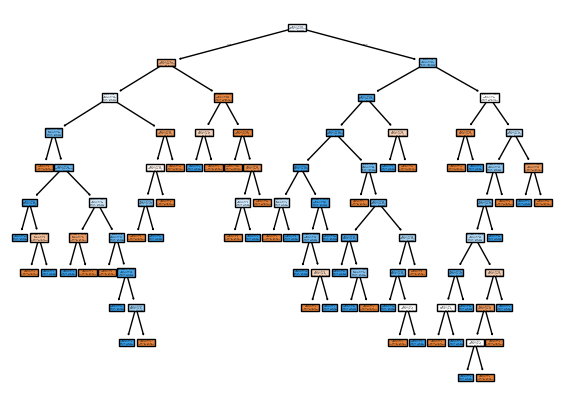

In [ ]:
id3 = DecisionTreeClassifier(criterion="entropy")  # ID3
id3.fit(X_train, y_train)
y_pred_id3 = id3.predict(X_test)
print("ID3 Accuracy:", accuracy_score(y_test, y_pred_id3))
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
tree.plot_tree(cart, feature_names=X.columns, class_names=["No Disease", "Disease"], filled=True)
plt.show()

In [ ]:
#c45 algo
c45 = DecisionTreeClassifier(criterion="entropy", splitter="best", max_depth=5)
c45.fit(X_train, y_train)
y_pred_c45 = c45.predict(X_test)
print("C4.5-like Accuracy:", accuracy_score(y_test, y_pred_c45))

C4.5-like Accuracy: 0.8798701298701299


In [ ]:
# ✅ Random Forest Classification on Heart/Cardiac Dataset

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Load dataset (you already uploaded your CSV in Colab)
df = pd.read_csv("cardiac arrest dataset.csv")   # replace with your file name if different
print(df.shape)
print(df.head())

# 2. Split into features (X) and target (y)
X = df.drop("target", axis=1)   # 'target' is the label column
y = df["target"]

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Build Random Forest model
rf = RandomForestClassifier(
    n_estimators=200,     # number of trees
    criterion="gini",     # or "entropy"
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# 5. Train
rf.fit(X_train, y_train)

# 6. Predict
y_pred = rf.predict(X_test)

# 7. Evaluate
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

(1025, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
Random Forest Accuracy: 1.0

Confusion Matrix:
 [[100   0]
 [  0 105]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
we